In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [127]:
print("Training data:")
print(train.columns)
# check multiple cabins
multiple_cabins = [item for item in train.Cabin if pd.notna(item) and len(item.split(' ')) > 1]
letter_tickets = [item for item in train.Ticket if len(item.split(' ')) > 1]
letter_tickets


Training data:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


['A/5 21171',
 'PC 17599',
 'STON/O2. 3101282',
 'PP 9549',
 'A/5. 2151',
 'PC 17601',
 'PC 17569',
 'C.A. 24579',
 'PC 17604',
 'A./5. 2152',
 'SC/Paris 2123',
 'S.C./A.4. 23567',
 'A/4. 39886',
 'PC 17572',
 'C.A. 31026',
 'C.A. 34651',
 'CA 2144',
 'PC 17605',
 'C.A. 29395',
 'S.P. 3464',
 'C.A. 33111',
 'CA 2144',
 'S.O.C. 14879',
 'SO/C 14885',
 'W./C. 6608',
 'SOTON/OQ 392086',
 'W.E.P. 5734',
 'C.A. 2315',
 'PC 17754',
 'PC 17759',
 'STON/O 2. 3101294',
 'PC 17558',
 'S.O.C. 14879',
 'A4. 54510',
 'C 17369',
 'SOTON/O.Q. 3101307',
 'A/5. 3337',
 'C.A. 29178',
 'SC/PARIS 2133',
 'PC 17593',
 'STON/O2. 3101279',
 'C.A. 33112',
 'W./C. 6608',
 'S.O.P. 1166',
 'A.5. 11206',
 'A/5. 851',
 'Fa 265302',
 'PC 17597',
 'SOTON/OQ 392090',
 'CA. 2343',
 'C.A. 33595',
 'PC 17318',
 'STON/O 2. 3101280',
 'PC 17595',
 'CA. 2343',
 'SC/PARIS 2131',
 'PC 17610',
 'PC 17569',
 'CA. 2343',
 'A/5 3540',
 'SOTON/O.Q. 3101311',
 'F.C.C. 13528',
 'A/5 21174',
 'STON/O2. 3101283',
 'W/C 14208',
 'SOTO

In [128]:
print("Testing data:")
test.head()

Testing data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [129]:
train['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.nan
all_data = pd.concat([train, test], ignore_index=True)



**Understanding nature of data**  
.info() .describe()  
histograms, metric correlations  
interesting themes  
feature engineering  

In [130]:
all_data.info()
all_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  train_test   1309 non-null   int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 133.1+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,0.680672
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,0.466394
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


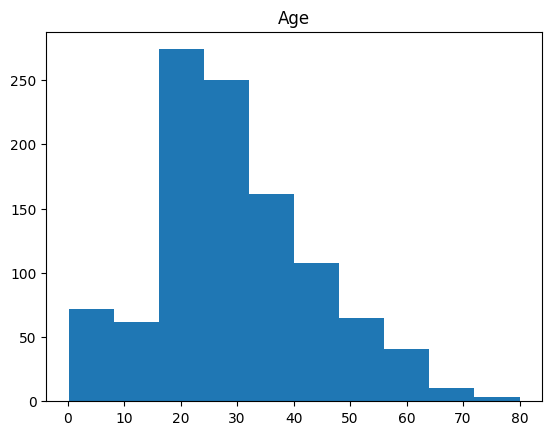

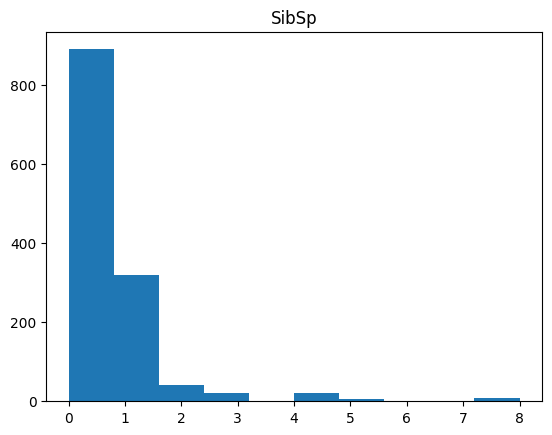

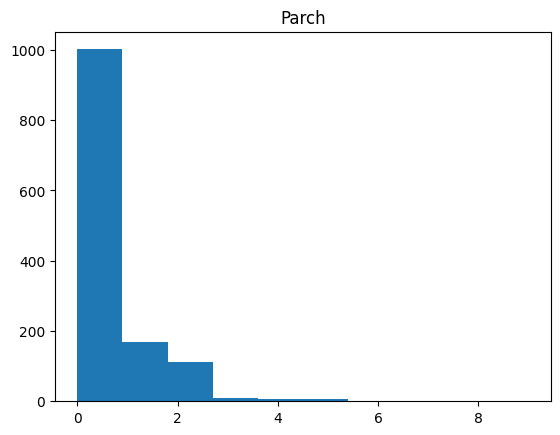

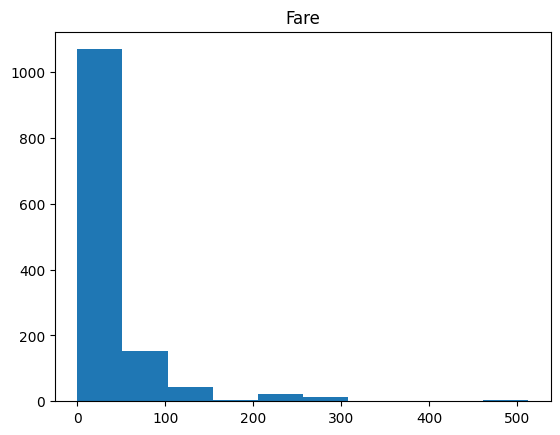

In [131]:
# break code into numerical and categorical data frames
df_num = all_data[['Age', 'SibSp', 'Parch', 'Fare']]
df_cat = all_data[['Survived', 'Pclass', 'Ticket', 'Cabin', 'Sex', 'Embarked']]

# distributions for numerical data
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.243699 -0.150917  0.178740
SibSp -0.243699  1.000000  0.373587  0.160238
Parch -0.150917  0.373587  1.000000  0.221539
Fare   0.178740  0.160238  0.221539  1.000000


<Axes: >

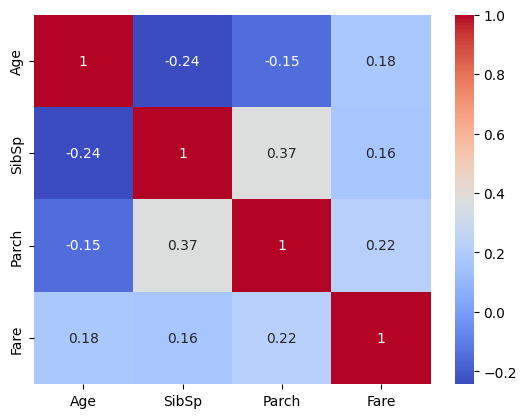

In [132]:
# visualize correlations with heatmap and .corr() from pandas
print(df_num.corr())
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')

**Observations**:  
age & siblings/spouses and age & parents/children have negative correlation  
siblings/spouses & parents/children have positive correlation (makes sense, multiple children means more siblings for those children)  
no multicollinearity --> good!

In [133]:
# compare survival rate across age, fare, parch, sibsp
pd.pivot_table(train, index='Survived', values=['Age', 'Fare', 'Parch', 'SibSp'], aggfunc='mean')

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


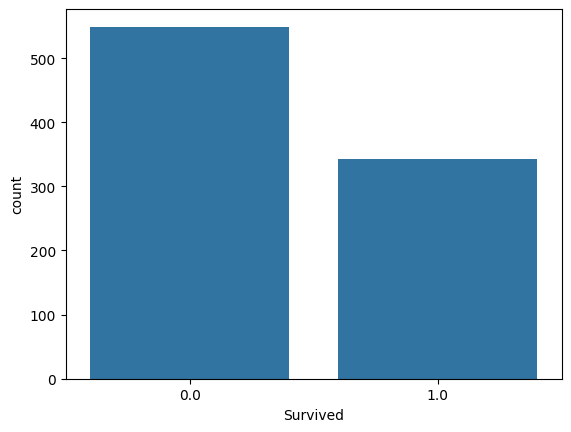

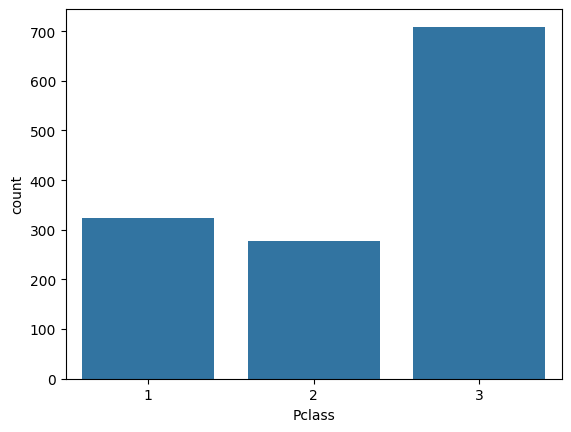

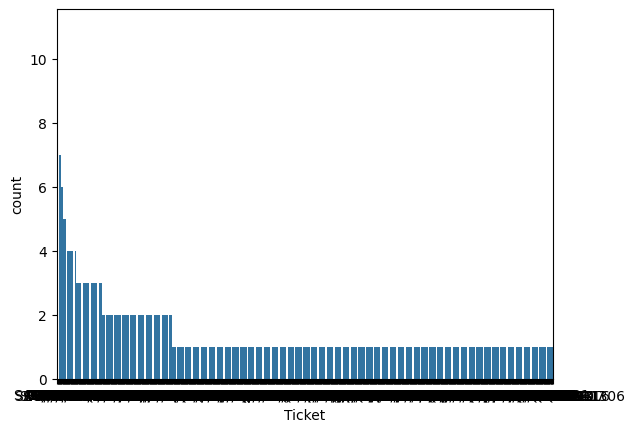

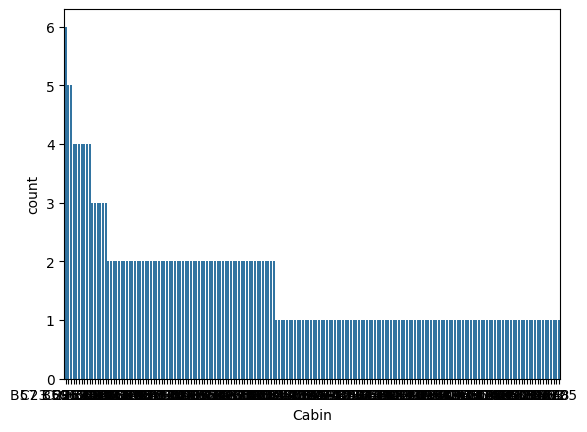

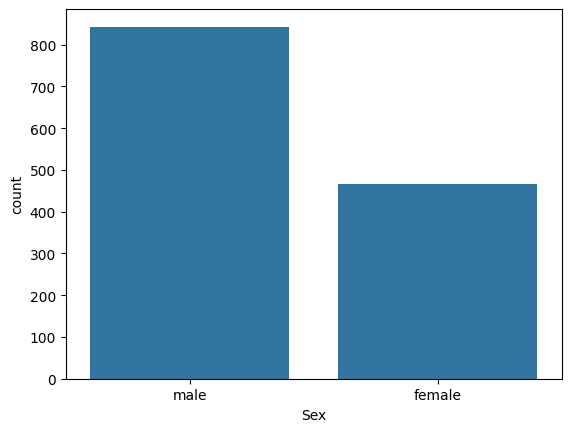

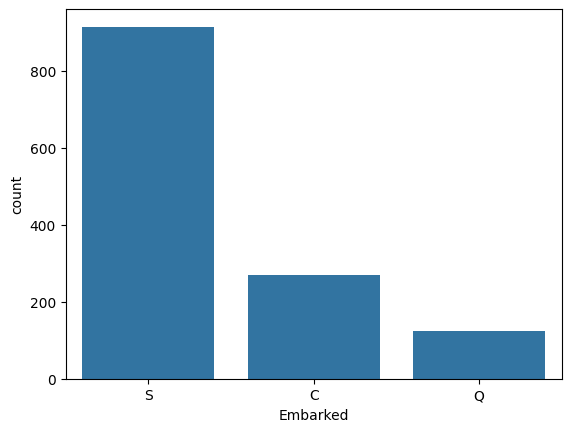

In [134]:
# barplots for categorical data
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index, y=df_cat[i].value_counts())
    plt.show()

In [135]:
# Comparing survival rate across categorical data
print(pd.pivot_table(train, index='Survived', columns='Sex', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(train, index='Survived', columns='Pclass', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(train, index='Survived', columns='Embarked', values='Ticket', aggfunc='count'))


Sex       female  male
Survived              
0             81   468
1            233   109

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


**Feature Engineering**
1) Cabin—simplify to cabin letter (cabin_adv) or purchase of tickets across multiple cabins (cabin_multiple)  
2) Tickets—different ticket types

In [136]:
df_cat.Cabin
train['cabin_multiple'] = train['Cabin'].apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
train['cabin_multiple'].value_counts()

cabin_multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

In [137]:
pd.pivot_table(train, index='Survived', columns='cabin_multiple', values='Ticket', aggfunc='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [138]:
# creates categories based on cabin letter
# null values treated as own category
train['cabin_adv'] = train['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'N')
train['cabin_adv'].value_counts()

cabin_adv
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [139]:
pd.pivot_table(train, index='Survived', columns='cabin_adv', values='Ticket', aggfunc='count')

cabin_adv,A,B,C,D,E,F,G,N,T
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,481.0,1.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,206.0,NaN


In [140]:
# understand ticket values better
# numeric vs non-numeric
train['ticket_numeric'] = train['Ticket'].apply(lambda x: 1 if x.isdigit() else 0)
train['ticket_letters'] = train.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.', '').replace('/', '').lower() if len(x.split(' ')[:-1]) > 0 else 0)

In [141]:
pd.set_option("display.max_rows", None)
train['ticket_letters'].value_counts()

ticket_letters
0            665
pc            60
ca            41
a5            21
stono2        18
sotonoq       15
scparis       11
wc            10
a4             7
soc            6
fcc            5
c              5
sopp           3
pp             3
wep            3
ppp            2
scah           2
sotono2        2
swpp           2
fc             1
scahbasle      1
as             1
sp             1
sc             1
scow           1
fa             1
sop            1
sca4           1
casoton        1
Name: count, dtype: int64

In [142]:
# difference in numeric vs non-numeric tickets on survival rate
pd.pivot_table(train, index='Survived', columns='ticket_numeric', values='Ticket', aggfunc='count')

ticket_numeric,0,1
Survived,,
0,142,407
1,88,254


In [143]:
# difference in ticket letters on survival rate
pd.pivot_table(train, index='Survived', columns='ticket_letters', values='Ticket', aggfunc='count')

ticket_letters,0,a4,a5,as,c,ca,casoton,fa,fc,fcc,...,soc,sop,sopp,sotono2,sotonoq,sp,stono2,swpp,wc,wep
Survived,,,,,,,,,,,,,,,,,,,,,
0,410.0,7.0,19.0,1.0,3.0,27.0,1.0,1.0,1.0,1.0,...,5.0,1.0,3.0,2.0,13.0,1.0,10.0,NaN,9.0,2.0
1,255.0,NaN,2.0,NaN,2.0,14.0,NaN,NaN,NaN,4.0,...,1.0,NaN,NaN,NaN,2.0,NaN,8.0,2.0,1.0,1.0


In [144]:
# feature engineering on person's title
train.Name.head(50)
# mr, mrs, miss, etc.
train['name_title'] = train['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
train['name_title'].value_counts()

name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [145]:
pd.pivot_table(train, index='Survived', columns='name_title', values='Ticket', aggfunc='count')

name_title,Capt,Col,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess
Survived,,,,,,,,,,,,,,,,,
0,1.0,1.0,1.0,4.0,1.0,NaN,1.0,17.0,55.0,NaN,NaN,436.0,26.0,NaN,6.0,NaN,NaN
1,NaN,1.0,NaN,3.0,NaN,1.0,1.0,23.0,127.0,2.0,1.0,81.0,99.0,1.0,NaN,1.0,1.0


**Data Preprocessing**  
1) Drop null values from Embarked (only 2)  
2) Only include relevant variables (exclude name and passenger ID)  
3) Categorical transformations on all data to ensure train and test have same columns  
4) Fill null values for continuous columns with mean (fare and age)  
5) Normalize fare using logarithm  
6) Scale data 0-1 with standard scaler

(889,)

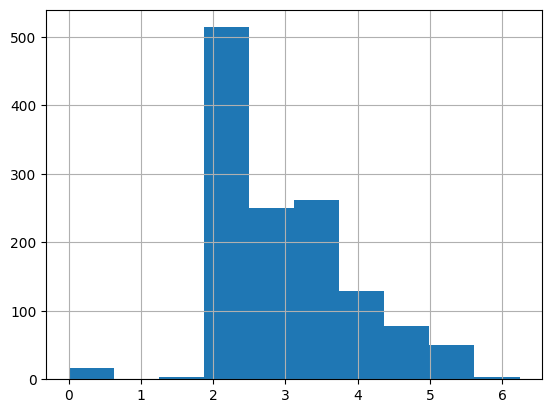

In [146]:
# create same categorical variables as done above
all_data['cabin_multiple'] = all_data['Cabin'].apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
all_data['cabin_adv'] = all_data['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'N')
all_data['ticket_numeric'] = all_data['Ticket'].apply(lambda x: 1 if x.isdigit() else 0)
all_data['ticket_letters'] = all_data.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.', '').replace('/', '').lower() if len(x.split(' ')[:-1]) > 0 else 0)
all_data['name_title'] = all_data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

# fill null values
# should use median for non-normal data
all_data.Age = all_data.Age.fillna(all_data.Age.mean())
all_data.Fare = all_data.Fare.fillna(all_data.Fare.mean())

# drop null embarked rows
all_data.dropna(subset=['Embarked'], inplace=True)

# log norm of fare
all_data['norm_fare'] = np.log(all_data['Fare'] + 1)
all_data['norm_fare'].hist()

# convert fare to categorical for pd.get_dummies
all_data.Pclass = all_data.Pclass.astype(str)

# create dummy variables from categories (can also use OneHotEncoder)
all_dummies = pd.get_dummies(all_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'norm_fare', 'Embarked', 'cabin_adv', 'cabin_multiple', 'name_title', 'ticket_numeric', 'train_test']])

# split to train test again
X_train = all_dummies[all_dummies['train_test'] == 1].drop('train_test', axis=1)
X_test = all_dummies[all_dummies['train_test'] == 0].drop('train_test', axis=1)

y_train = all_data[all_data['train_test'] == 1]['Survived']
y_train.shape

In [147]:
# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

all_dummies_scaled = all_dummies.copy()
all_dummies_scaled[['Age', 'SibSp', 'Parch', 'norm_fare']] = scaler.fit_transform(all_dummies[['Age', 'SibSp', 'Parch', 'norm_fare']])

X_train_scaled = all_dummies_scaled[all_dummies_scaled['train_test'] == 1].drop('train_test', axis=1)
X_test_scaled = all_dummies_scaled[all_dummies_scaled['train_test'] == 0].drop('train_test', axis=1)

y_train = all_data[all_data['train_test'] == 1]['Survived']



In [148]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC

**K-fold Cross-Validation**  
k folds (k subsets of training data)  
Train on k-1 folds, test on remaining 1 fold k times (each fold gets tested once)  

A high score on validation does not always result to scoring well on test data!

In [149]:
# Naive Bayes as baseline for classification tasks
gnb = GaussianNB()
cv = cross_val_score(gnb, X_train, y_train, cv=5)
print(cv)
print(cv.mean())

[0.66853933 0.70224719 0.76966292 0.75842697 0.72881356]
0.7255379927632831


In [150]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000)
cv = cross_val_score(lr, X_train, y_train, cv=5)
print(cv)
print(cv.mean())

[0.82022472 0.80898876 0.80337079 0.82022472 0.85310734]
0.8211832666793626


In [151]:
# Logistic Regression with scaled data
lr = LogisticRegression(max_iter=2000)
cv = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print(cv)
print(cv.mean())

[0.82022472 0.80898876 0.80337079 0.82022472 0.85310734]
0.8211832666793626


In [152]:
# Decision Tree
dt = tree.DecisionTreeClassifier(random_state=1)
cv = cross_val_score(dt, X_train, y_train, cv=5)
print(cv)
print(cv.mean())


[0.74719101 0.75842697 0.84831461 0.76404494 0.83615819]
0.7908271440360567


In [153]:
# Decision Tree with scaled data
# random_state used for reproducibility
dt = tree.DecisionTreeClassifier(random_state = 1)
cv = cross_val_score(dt,X_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.74719101 0.75842697 0.84831461 0.76404494 0.83615819]
0.7908271440360567


In [154]:
# K-Nearest Neighbors
knn = KNeighborsClassifier()
cv = cross_val_score(knn,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.76966292 0.80337079 0.80337079 0.81460674 0.83615819]
0.8054338856090902


In [155]:
# K-Nearest Neighbors with scaled data
# affected by data scale because KNN uses distance between data points
knn = KNeighborsClassifier()
cv = cross_val_score(knn,X_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.79775281 0.79213483 0.83146067 0.80337079 0.85310734]
0.8155652891512728


In [156]:
# Random Forest
rf = RandomForestClassifier(random_state = 1)
cv = cross_val_score(rf,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.79775281 0.7752809  0.84831461 0.73033708 0.82485876]
0.7953088300641149


In [157]:
# Random Forest with scaled data
rf = RandomForestClassifier(random_state = 1)
cv = cross_val_score(rf,X_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.79775281 0.7752809  0.84831461 0.73033708 0.82485876]
0.7953088300641149


In [158]:
# Support Vector Machine
svc = SVC(probability = True)
cv = cross_val_score(svc,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.68539326 0.76966292 0.71348315 0.71910112 0.74011299]
0.7255506887576969


In [159]:
# Support Vector Machine with scaled data
# also distance-based algorithm, scaling --> features contribute equally
svc = SVC(probability = True)
cv = cross_val_score(svc,X_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.84831461 0.82022472 0.8258427  0.80337079 0.86440678]
0.8324319177299563


**Voting Classifier**    
Ensemble that combines predictions from multiple models (base estimators) and makes final decision based on a vote  
*Hard voting*: majority vote  
*Soft voting*: average probability (if >50%, counts as 1)

In [160]:
voting_clf = VotingClassifier(estimators = [('lr',lr),('knn',knn),('rf',rf),('gnb',gnb),('svc',svc)], voting = 'soft') 
cv = cross_val_score(voting_clf,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.78651685 0.79213483 0.81460674 0.79775281 0.85875706]
0.8099536596203898


In [ ]:
# trains (fit) voting classifier on scaled training features and target labels
voting_clf.fit(X_train_scaled,y_train)
# uses trained ensemble to predict survival on test set
y_hat_base_vc = voting_clf.predict(X_test_scaled).astype(int)
# creates submission file for Kaggle
basic_submission = {'PassengerId': test.PassengerId, 'Survived': y_hat_base_vc}
base_submission = pd.DataFrame(data=basic_submission)
base_submission.to_csv('base_submission.csv', index=False)

**Model Tuned Performance**  
Mainly use grid search to tune models and Randomized Search for Random Forest

In [163]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV 

In [164]:
#simple performance reporting function
def clf_performance(classifier, model_name):
    print(model_name)
    print('Best Score: ' + str(classifier.best_score_))
    print('Best Parameters: ' + str(classifier.best_params_))

In [165]:
lr = LogisticRegression()
param_grid = {'max_iter': [2000], 'penalty': ['l1', 'l2'], 'C': np.logspace(-4, 4, 20), 'solver': ['liblinear']}
clf_lr = GridSearchCV(lr, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_lr = clf_lr.fit(X_train_scaled, y_train)
clf_performance(best_clf_lr, 'Logistic Regression')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression
Best Score: 0.8268075922046594
Best Parameters: {'C': np.float64(1.623776739188721), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}


In [171]:
# print results for all 40 combinations
pd.set_option('display.max_colwidth', None)
results = pd.DataFrame(best_clf_lr.cv_results_)
sorted_results = results.sort_values(by = 'rank_test_score')
sorted_results[['params', 'mean_test_score', 'rank_test_score']].head()


,params,mean_test_score,rank_test_score
20,"{'C': 1.623776739188721, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}",0.826808,1
24,"{'C': 11.288378916846883, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}",0.823437,2
26,"{'C': 29.763514416313132, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}",0.822320,3
38,"{'C': 10000.0, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}",0.822320,3
29,"{'C': 78.47599703514607, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'liblinear'}",0.822320,3


In [172]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9],
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto', 'ball_tree','kd_tree'],
              'p' : [1,2]}
clf_knn = GridSearchCV(knn, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_knn = clf_knn.fit(X_train_scaled,y_train)
clf_performance(best_clf_knn,'KNN')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN
Best Score: 0.8267948962102457
Best Parameters: {'algorithm': 'kd_tree', 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


In [173]:
svc = SVC(probability = True)
param_grid = tuned_parameters = [{'kernel': ['rbf'], 'gamma': [.1,.5,1,2,5,10],
                                  'C': [.1, 1, 10, 100, 1000]},
                                 {'kernel': ['linear'], 'C': [.1, 1, 10, 100, 1000]},
                                 {'kernel': ['poly'], 'degree' : [2,3,4,5], 'C': [.1, 1, 10, 100, 1000]}]
clf_svc = GridSearchCV(svc, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_svc = clf_svc.fit(X_train_scaled,y_train)
clf_performance(best_clf_svc,'SVC')

Fitting 5 folds for each of 55 candidates, totalling 275 fits
SVC
Best Score: 0.8324319177299563
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


**RandomizedSearchCV**  
Can estimate best model parameters using this approach and then trying out more specific values around those tuned hyperparameters later.  
E.g. randomized search --> n_estimators: 500, then can use grid search to try 450, 480, 520, etc.

In [179]:
rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [100,500,1000], 
                'bootstrap': [True,False],
                'max_depth': [3,5,10,20,50,75,100,None],
                'max_features': ['log2','sqrt'],
                'min_samples_leaf': [1,2,4,10],
                'min_samples_split': [2,5,10]}
                                  
clf_rf_rnd = RandomizedSearchCV(rf, param_distributions = param_grid, n_iter = 100, cv = 5, verbose = True, n_jobs = -1, error_score='raise')
best_clf_rf_rnd = clf_rf_rnd.fit(X_train_scaled,y_train)
clf_performance(best_clf_rf_rnd,'Random Forest')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Random Forest
Best Score: 0.8357836602551896
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}


In [182]:
rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [70, 90, 110, 130],
               'criterion':['gini','entropy'],
                'bootstrap': [True],
                'max_depth': [15, 20, 25, None],
                'max_features': ['log2','sqrt', 10],
                'min_samples_leaf': [2],
                'min_samples_split': [2]}
                                  
clf_rf = GridSearchCV(rf, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1, error_score='raise')
best_clf_rf = clf_rf.fit(X_train_scaled,y_train)
clf_performance(best_clf_rf,'Random Forest')

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Random Forest
Best Score: 0.8391734907636641
Best Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 25, 'max_features': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 70}


<Axes: >

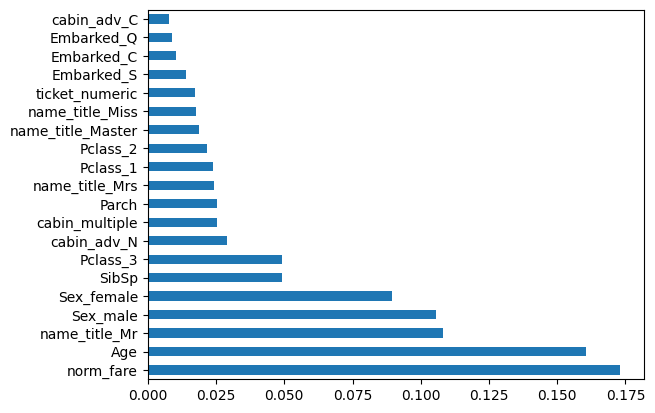

In [183]:
best_rf = best_clf_rf.best_estimator_.fit(X_train_scaled,y_train)
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns)
feat_importances.nlargest(20).plot(kind='barh')

**Model Additional Ensemble Approaches**
1) Experimented with a hard voting classifier of three estimators (KNN, SVM, RF) (81.6%)

2) Experimented with a soft voting classifier of three estimators (KNN, SVM, RF) (82.3%) (Best Performance)

3) Experimented with soft voting on all estimators performing better than 80% except xgb (KNN, RF, LR, SVC) (82.9%)

In [184]:
best_lr = best_clf_lr.best_estimator_
best_knn = best_clf_knn.best_estimator_
best_svc = best_clf_svc.best_estimator_
best_rf = best_clf_rf.best_estimator_

voting_clf_hard = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'hard') 
voting_clf_soft = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'soft') 
voting_clf_all = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc), ('lr', best_lr)], voting = 'soft') 

print('voting_clf_hard :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5))
print('voting_clf_hard mean :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5).mean())

print('voting_clf_soft :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5))
print('voting_clf_soft mean :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5).mean())

print('voting_clf_all :',cross_val_score(voting_clf_all,X_train,y_train,cv=5))
print('voting_clf_all mean :',cross_val_score(voting_clf_all,X_train,y_train,cv=5).mean())

voting_clf_hard : [0.79775281 0.81460674 0.82022472 0.80337079 0.83615819]
voting_clf_hard mean : 0.8144226496540341
voting_clf_soft : [0.79775281 0.82022472 0.82022472 0.80337079 0.86440678]
voting_clf_soft mean : 0.8200723671681585
voting_clf_all : [0.81460674 0.83146067 0.83146067 0.81460674 0.86440678]
voting_clf_all mean : 0.8313083222243384


In [ ]:
#in a soft voting classifier you can weight some models more than others. I used a grid search to explore different weightings
#no new results here
params = {'weights' : [[1,1,1],[1,2,1],[1,1,2],[2,1,1],[2,2,1],[1,2,2],[2,1,2]]}

vote_weight = GridSearchCV(voting_clf_soft, param_grid = params, cv = 5, verbose = True, n_jobs = -1)
best_clf_weight = vote_weight.fit(X_train_scaled,y_train)
clf_performance(best_clf_weight,'VC Weights')
voting_clf_sub = best_clf_weight.best_estimator_.predict(X_test_scaled)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
VC Weights
Best Score: 0.833568209229988
Best Parameters: {'weights': [1, 1, 1]}


In [186]:
#Make Predictions 
voting_clf_hard.fit(X_train_scaled, y_train)
voting_clf_soft.fit(X_train_scaled, y_train)
voting_clf_all.fit(X_train_scaled, y_train)

best_rf.fit(X_train_scaled, y_train)
y_hat_vc_hard = voting_clf_hard.predict(X_test_scaled).astype(int)
y_hat_rf = best_rf.predict(X_test_scaled).astype(int)
y_hat_vc_soft =  voting_clf_soft.predict(X_test_scaled).astype(int)
y_hat_vc_all = voting_clf_all.predict(X_test_scaled).astype(int)

In [187]:
#Accuracies
print('voting_clf_hard :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5))
print('voting_clf_hard mean :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5).mean())

print('voting_clf_soft :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5))
print('voting_clf_soft mean :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5).mean())

print('voting_clf_all :',cross_val_score(voting_clf_all,X_train,y_train,cv=5))
print('voting_clf_all mean :',cross_val_score(voting_clf_all,X_train,y_train,cv=5).mean())

voting_clf_hard : [0.79775281 0.81460674 0.82022472 0.80337079 0.83615819]
voting_clf_hard mean : 0.8144226496540341
voting_clf_soft : [0.79213483 0.81460674 0.8258427  0.80337079 0.86440678]
voting_clf_soft mean : 0.8189487716625405
voting_clf_all : [0.81460674 0.83146067 0.83146067 0.81460674 0.86440678]
voting_clf_all mean : 0.8313083222243384
